# Fine-tuning a YOLOv8 License Plate Detector

**Goal:** fine-tune a pretrained YOLOv8 detector to localize license plates in
images/video frames, as the first stage of the forensic enhancement pipeline.

**Why fine-tune instead of using a generic pretrained detector?**
- Generic object detectors (COCO-pretrained) don't have a "license plate"
  class at all, and a Haar cascade (our zero-dependency fallback) has poor
  recall on angled/low-light/foreign-format plates.
- Plate detection is a narrow, well-defined, single-class problem, so even a
  small model (YOLOv8n/s) fine-tuned on a few thousand images reaches strong
  precision/recall quickly, and stays fast enough for near-real-time video.

**Dataset:** We use an open license-plate detection dataset in YOLO format.
Good public options (pick based on availability at run time):
- CCPD (Chinese City Parking Dataset) — very large, many degradation types
- Roboflow Universe "License Plate Recognition" datasets — bounding boxes,
  YOLO-format export, easy to plug in
- Any custom-labeled set exported from Roboflow / CVAT / LabelImg in YOLO format

This notebook is dataset-agnostic: it expects a standard YOLO-detection
folder layout (`images/train`, `images/val`, `labels/train`, `labels/val`,
and a `data.yaml`). Point `DATASET_YAML` at your dataset's `data.yaml`.


In [1]:
!rm -f /kaggle/working/yolov8n.pt yolov8n.pt

In [2]:
# If running in a fresh environment (e.g. Colab), install dependencies:
!pip install ultralytics==8.2.103 opencv-python-headless pyyaml


In [3]:
!pip uninstall ray -y

In [4]:
!ls -la /kaggle/input/datasets/
!ls -la /kaggle/input/datasets/sujaymann/

total 12
drwxr-xr-x 3 root root 4096 Sep 10 09:34 .
drwxr-xr-x 3 root root 4096 Sep 10 09:34 ..
drwxr-xr-x 3 root root 4096 Sep 10 09:34 sujaymann
total 8
drwxr-xr-x 3 root   root    4096 Sep 10 09:34 .
drwxr-xr-x 3 root   root    4096 Sep 10 09:34 ..
drwxr-xr-x 3 nobody nogroup    0 Sep 10 09:17 car-number-plate-dataset-yolo-format


In [5]:
import os
from ultralytics import YOLO
import yaml
from pathlib import Path

BASE = Path("/kaggle/input/datasets/sujaymann/car-number-plate-dataset-yolo-format/License-Plate-Data")
DATASET_YAML = BASE / "data.yaml"
MODEL_OUT_DIR = Path("/kaggle/working/plate_detector_output")
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset yaml:", DATASET_YAML)
print("Exists:", DATASET_YAML.exists())

Dataset yaml: /kaggle/input/datasets/sujaymann/car-number-plate-dataset-yolo-format/License-Plate-Data/data.yaml
Exists: True


In [6]:
!cat "{DATASET_YAML}"

names:
  0: license_plate
nc: 1
train: /kaggle/input/car-number-plate-dataset-yolo-format/License-Plate-Data/train
val: /kaggle/input/car-number-plate-dataset-yolo-format/License-Plate-Data/test

In [7]:
yaml_content = f"""train: {BASE / "train" / "images"}
val: {BASE / "test" / "images"}
nc: 1
names: ['license_plate']
"""

fixed_yaml_path = Path("/kaggle/working/data.yaml")
fixed_yaml_path.write_text(yaml_content)

DATASET_YAML = fixed_yaml_path
print(DATASET_YAML.read_text())

print(len(list((BASE / "train" / "images").glob("*.png"))), "train images")
print(len(list((BASE / "test" / "images").glob("*.png"))), "test images")

train: /kaggle/input/datasets/sujaymann/car-number-plate-dataset-yolo-format/License-Plate-Data/train/images
val: /kaggle/input/datasets/sujaymann/car-number-plate-dataset-yolo-format/License-Plate-Data/test/images
nc: 1
names: ['license_plate']

346 train images
87 test images


In [8]:
print(DATASET_YAML)
print(DATASET_YAML.read_text())

/kaggle/working/data.yaml
train: /kaggle/input/datasets/sujaymann/car-number-plate-dataset-yolo-format/License-Plate-Data/train/images
val: /kaggle/input/datasets/sujaymann/car-number-plate-dataset-yolo-format/License-Plate-Data/test/images
nc: 1
names: ['license_plate']



## 1. Inspect the dataset

Before training, sanity-check class balance and a few sample annotations —
mislabeled or missing boxes are the single most common cause of a
disappointing fine-tune, and are much cheaper to catch here than after a
multi-hour training run.


In [9]:
if DATASET_YAML.exists():
    with open(DATASET_YAML) as f:
        data_cfg = yaml.safe_load(f)
    print(data_cfg)
else:
    print("Dataset not found at the configured path.\n"
          "Download a YOLO-format plate detection dataset (e.g. from Roboflow "
          "Universe) and update DATASET_YAML above before proceeding.")


{'train': '/kaggle/input/datasets/sujaymann/car-number-plate-dataset-yolo-format/License-Plate-Data/train/images', 'val': '/kaggle/input/datasets/sujaymann/car-number-plate-dataset-yolo-format/License-Plate-Data/test/images', 'nc': 1, 'names': ['license_plate']}


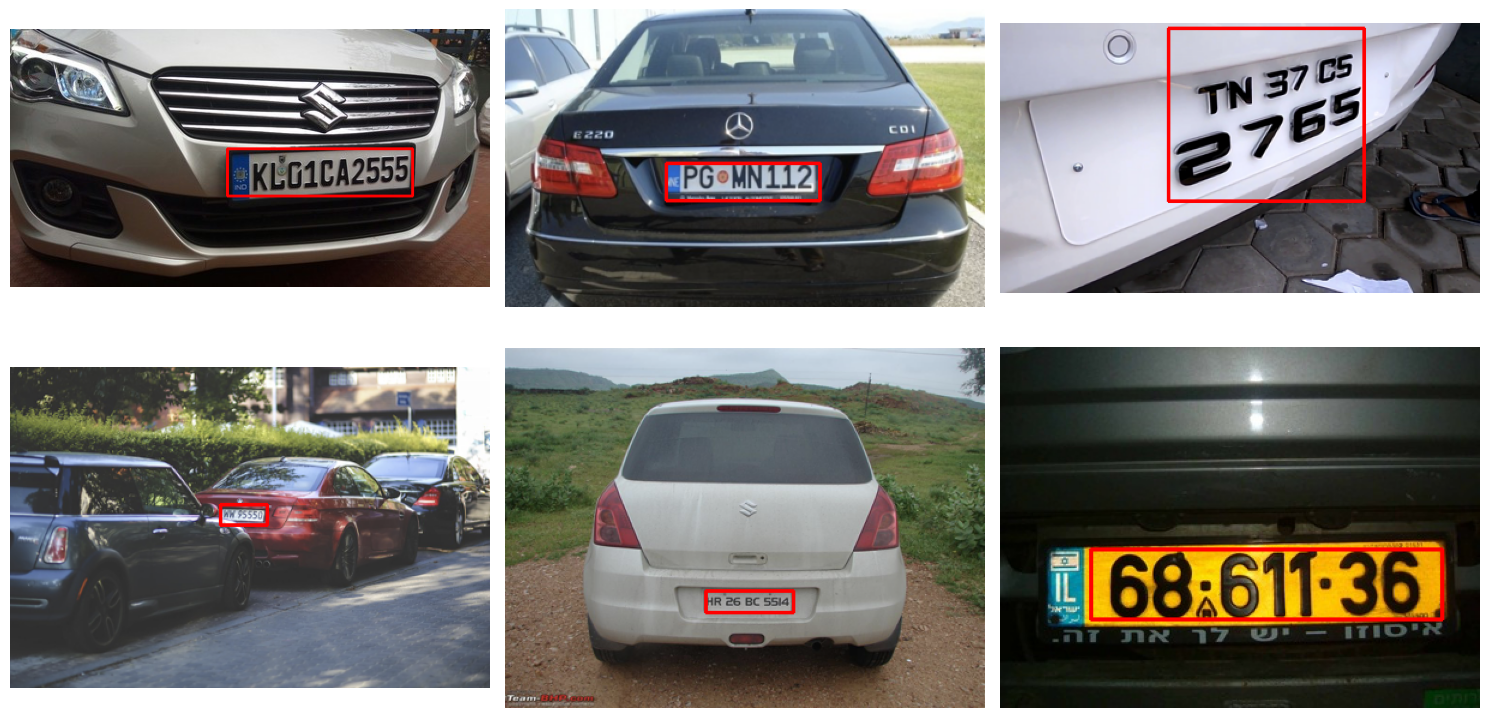

In [10]:
import cv2
import matplotlib.pyplot as plt

def visualize_sample(images_dir, labels_dir, n=6):
    image_files = sorted(Path(images_dir).glob("*.png"))[:n]   # <-- .png not .jpg
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, img_path in zip(axes.flat, image_files):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        label_path = Path(labels_dir) / (img_path.stem + ".txt")
        if label_path.exists():
            for line in open(label_path):
                cls, cx, cy, bw, bh = map(float, line.split())
                x1, y1 = int((cx - bw / 2) * w), int((cy - bh / 2) * h)
                x2, y2 = int((cx + bw / 2) * w), int((cy + bh / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        ax.imshow(img)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# use BASE (your real dataset root), not DATASET_YAML.parent
visualize_sample(BASE / "train" / "images", BASE / "train" / "labels")

## 2. Fine-tune YOLOv8

We start from `yolov8n.pt` (smallest/fastest) as the base — nano is usually
sufficient for a single-class, moderately-sized-object detection task, and
keeps inference cheap enough to run per-frame on video during the
multi-frame fusion stage. Swap to `yolov8s.pt` if validation recall is
insufficient and inference budget allows.

Augmentation choices below specifically target the degradations named in the
assignment brief (motion blur, low light, angle, noise) so the *detector*
itself is robust to degraded input, not just the downstream enhancement
stages.


In [11]:
!pip uninstall wandb -y

Found existing installation: wandb 0.26.1
Uninstalling wandb-0.26.1:
  Successfully uninstalled wandb-0.26.1


In [12]:
from ultralytics import settings
settings.update({"wandb": False})
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"




BASE_MODEL = "yolov8n.pt"
EPOCHS = 100
IMG_SIZE = 640
BATCH = 16

model = YOLO(BASE_MODEL)

results = model.train(
    data=str(DATASET_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    patience=15,                 # early stopping
    project=str(MODEL_OUT_DIR.parent),
    name="plate_detector",
    exist_ok=True,

    # Augmentations chosen to mimic forensic footage degradations:
    degrees=10,                  # camera/plate tilt
    perspective=0.0005,          # off-axis viewing angle
    hsv_v=0.4,                   # brightness variation (day/night, headlight glare)
    hsv_s=0.3,                   # saturation variation (compression artifacts)
    mosaic=0.5,                  # scale/context variety
    fliplr=0.0,                  # plates are not left-right symmetric in general -> disable
)


100%|██████████| 6.25M/6.25M [00:00<00:00, 72.5MB/s]


New https://pypi.org/project/ultralytics/8.4.146 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/working/data.yaml, epochs=100, time=None, patience=15, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=/kaggle/working, name=plate_detector, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None

train: Scanning /kaggle/input/datasets/sujaymann/car-number-plate-dataset-yolo-format/License-Plate-Data/train/labels... 346 images, 0 backgrounds, 0 corrupt: 100%|██████████| 346/346 [00:00<00:00, 444.11it/s]

train: WARNING ⚠️ Cache directory /kaggle/input/datasets/sujaymann/car-number-plate-dataset-yolo-format/License-Plate-Data/train is not writeable, cache not saved.


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

     33/100      2.15G      1.319     0.8401      1.259         13        640: 100%|██████████| 22/22 [00:04<00:00,  4.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  5.38it/s]

                   all         87         87      0.906      0.793      0.845      0.308
EarlyStopping: Training stopped early as no improvement observed in last 15 epochs. Best results observed at epoch 18, best model saved as best.pt.
To update EarlyStopping(patience=15) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



33 epochs completed in 0.059 hours.
Optimizer stripped from /kaggle/working/plate_detector/weights/last.pt, 6.2MB
Optimizer stripped from /kaggle/working/plate_detector/weights/best.pt, 6.2MB

Validating /kaggle/working/plate_detector/weights/best.pt...
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.36it/s]


                   all         87         87      0.855      0.816      0.905      0.476
Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /kaggle/working/plate_detector


**Note on `blur` augmentation:** Ultralytics' built-in augmentation set does
not include a dedicated motion-blur op. If your ultralytics version lacks
it, either (a) drop that argument, or (b) pre-augment a copy of the training
set with `albumentations.MotionBlur` / `GaussNoise` and mix it into the
training folder — this often helps more than relying on inference-time
robustness alone, since it teaches the detector to still find the plate
*before* our enhancement stages run.


## 3. Validate and inspect failure cases


In [13]:
metrics = model.val(data=str(DATASET_YAML))
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.p)
print("Recall:", metrics.box.r)


Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /kaggle/input/datasets/sujaymann/car-number-plate-dataset-yolo-format/License-Plate-Data/test/labels... 87 images, 0 backgrounds, 0 corrupt: 100%|██████████| 87/87 [00:00<00:00, 399.69it/s]

val: WARNING ⚠️ Cache directory /kaggle/input/datasets/sujaymann/car-number-plate-dataset-yolo-format/License-Plate-Data/test is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:01<00:00,  3.19it/s]


                   all         87         87      0.844      0.793      0.903      0.477
Speed: 0.3ms preprocess, 10.4ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /kaggle/working/plate_detector
mAP50: 0.9027869105856534
mAP50-95: 0.4772519557599644
Precision: [    0.84357]
Recall: [     0.7931]



0: 640x640 2 license_plates, 6.3ms
1: 640x640 3 license_plates, 6.3ms
2: 640x640 2 license_plates, 6.3ms
3: 640x640 1 license_plate, 6.3ms
4: 640x640 1 license_plate, 6.3ms
5: 640x640 1 license_plate, 6.3ms
Speed: 2.9ms preprocess, 6.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


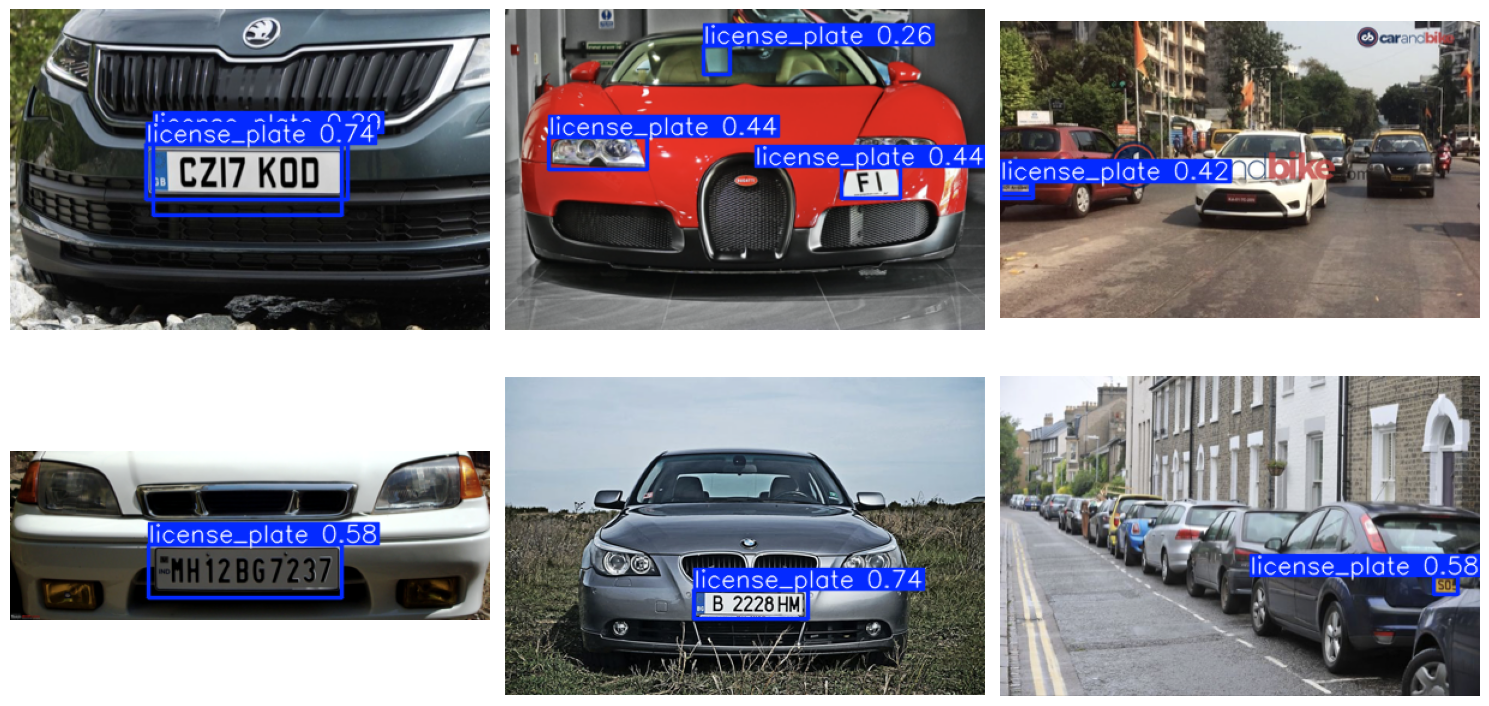

In [14]:
# Qualitative check: run inference on a handful of validation images and
# visualize predictions vs. ground truth, to spot systematic failure modes
# (e.g. small/distant plates, extreme angles, glare) worth writing up in the report.
val_images_dir = BASE / "test" / "images"          # <-- BASE, not DATASET_YAML.parent; "test" not "val"
sample_imgs = sorted(Path(val_images_dir).glob("*.png"))[:6] if val_images_dir.exists() else []

if sample_imgs:
    preds = model.predict([str(p) for p in sample_imgs], conf=0.25)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, pred in zip(axes.flat, preds):
        img = pred.plot()  # ultralytics helper: draws boxes on a copy of the image
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 4. Export the best checkpoint for the pipeline

The trained weights land at
`models/plate_detector/plate_detector/weights/best.pt` — copy/rename to the
path expected by `configs/config.yaml` (`detection.weights`).


In [16]:
import shutil
from pathlib import Path

best_ckpt = Path("/kaggle/working/plate_detector/weights/best.pt")
final_path = Path("/kaggle/working/best.pt")

if best_ckpt.exists():
    shutil.copy(best_ckpt, final_path)
    print(f"Copied fine-tuned weights to {final_path}")
else:
    print("Checkpoint not found at", best_ckpt)

Copied fine-tuned weights to /kaggle/working/best.pt
